In [1]:
import numpy as np
from scipy.spatial import Voronoi,voronoi_plot_2d
import matplotlib.pyplot as plt
import random as rnd
from svg_plot import SVGPlot
from IPython.display import display, HTML,Javascript,clear_output


In [ ]:
NUMBER_OF AREAs = 10

In [2]:
# 1. Generate 20 random 2D points (centers) in the range [0, 10]
np.random.seed(42)  # For reproducible results
points = np.random.rand(40, 2) * 10  # 20 rows, 2 columns, scale to 0-10

In [3]:
# 2. Create Voronoi diagram from these points
vor = Voronoi(points)

**`Voronoi(points)`**  
   The core calculation. It computes:
   - `vor.vertices`: The corner points where boundaries meet
   - `vor.ridge_vertices`: Which vertices connect to form boundaries
   - `vor.regions`: List of points for each polygon region
   - `vor.points`: Your original input points


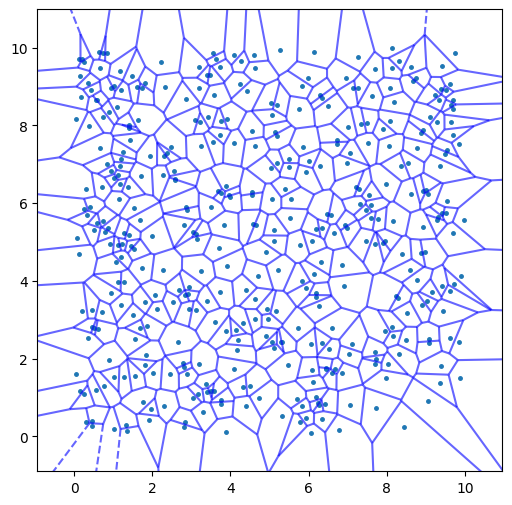

In [4]:
# 3. Plot the Voronoi diagram
fig, ax = plt.subplots(figsize=(6, 6))

# This function draws:
# - Ridge lines (the boundaries between regions)
# - Original points (centers)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue', 
                line_width=1.5, line_alpha=0.6, point_size=5)
plt.show()

In [5]:
polygons = []
for i in range(len(points)):
    region_idx = vor.point_region[i]
    region = vor.regions[region_idx]
    if region and -1 not in region:
        polygon = vor.vertices[region]
        polygon = vor.vertices[region]
        x_min, y_min = polygon.min(axis=0)  # [min_x, min_y]
        x_max, y_max = polygon.max(axis=0)  # [max_x, max_y]
        if(max([x_max,y_max])<10) and (min([x_min,y_min])>0):
            polygons.append(polygon)

```python
if region and -1 not in region:
```
This checks two things:

### 1. `if region` - Ensures the region is not empty
Sometimes `vor.regions` can contain empty lists (`[]`). This check skips those.

### 2. `-1 not in region` - Filters out unbounded regions

**`-1` is a special marker** in scipy's Voronoi implementation that indicates **"infinity"** or an **open/unbounded** edge.

- **If a region contains `-1`** → It extends to infinity (touches the diagram's border)
- **If a region has NO `-1`** → It's a closed polygon (completely bounded by other points)



**Summary:** This condition keeps only the "complete" polygons that are fully surrounded by other points, ignoring edge regions that extend to the diagram's borders.

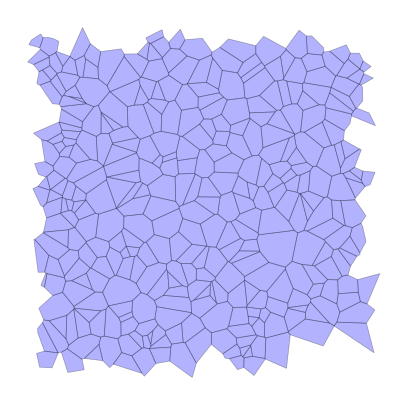

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Plot only the selected polygons (within circle)
for polygon in polygons:
    ax.fill(polygon[:, 0], polygon[:, 1], alpha=0.3, edgecolor='black', facecolor="blue",linewidth=0.5)
plt.axis('off')
plt.show()

In [7]:
svg = SVGPlot(500, 500, 10)

output_display = display(HTML("<div id='sim-container'>Loading...</div>"), display_id=True)
svg.clear()
for vertices in polygons:
    svg.add_polygon(vertices,'rgb(200,255,200)')
new_svg = svg.get_canvas()
output_display.update(HTML(f"<div id='sim-container'>{new_svg}</div>"))
